In [1]:
%reload_ext autoreload
%autoreload 2

# Hypothesis Testing of Timeout Impact via the GLRT

We model each timeout-impact metric as iid Gaussian observations $X_1,\dots,X_n \sim \mathcal{N}(\mu, \sigma^2)$ with unknown $\sigma^2$, and test

$$H_0: \mu = 0 \qquad \text{vs.} \qquad H_1: \mu \neq 0.$$

The generalized likelihood ratio is

$$\Lambda = \frac{\sup_{\sigma^2} L(0, \sigma^2)}{\sup_{\mu, \sigma^2} L(\mu, \sigma^2)} = \Big(\frac{\hat{\sigma}^2_1}{\hat{\sigma}^2_0}\Big)^{n/2},$$

where $\hat{\sigma}^2_0 = \tfrac{1}{n}\sum x_i^2$ and $\hat{\sigma}^2_1 = \tfrac{1}{n}\sum (x_i-\bar{x})^2 = \hat{\sigma}^2_0 - \bar{x}^2$. Thus

$$G = -2\log\Lambda = n \log\!\Big(1 + \frac{\bar{x}^2}{\hat{\sigma}^2_1}\Big),$$

which is asymptotically $\chi^2_1$ under $H_0$. We reject $H_0$ at level $\alpha=0.05$ when $G > 3.841$.

We test three metrics, each conditioned on each timeout subtype and stratified by context:

| Metric | Definition | What 0 means |
|---|---|---|
| Q1 `excess_net_post` | Net pts in 6 possessions after timeout, minus expected from season-PPP gap. | Calling team performs at season expectation in the post window. |
| Q2 `excess_ppp_for_post` | Calling team's PPP in 6 post possessions, minus that team's season PPP. | Calling team scores at season pace. |
| Q3 `wp_added_calling` | Change in calling-team WP across the timeout window, from a logistic WP model. | Window had no net WP movement. |

Each section below runs the GLRT overall by subtype and across the README context slices (home/away, regular vs playoff, time bucket, score-margin bucket, streak bucket), and saves a JPEG of the result into `Report/stats-signals/figures/`.

## Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_polars._core.polars_nb_imports import *

from nba_timeout_impact.nb_imports import *

from nba_timeout_impact.analyses.timeout_impact import (
    attach_baselines,
    build_timeout_events,
    compute_h2h_pt_diff,
    compute_team_season_ppp,
)
from nba_timeout_impact.analyses.wp_model import (
    build_wp_dataset,
    compute_wp_added,
    evaluate_wp_model,
    train_wp_model,
)
from nba_timeout_impact.analyses.glrt import (
    add_decision_columns,
    critical_value,
    glrt_zero_mean_gaussian,
    plot_glrt_by_slice,
    plot_glrt_distribution,
    plot_glrt_overall,
    run_glrt_groups,
)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from pathlib import Path

FIG_DIR = Path('/Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/Report/stats-signals/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'figures will be saved to {FIG_DIR}')

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env


[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0870 seconds


figures will be saved to /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/Report/stats-signals/figures


## Load Data

In [3]:
memo = CDNNBAMemoPL.load_all()

  Injected 14,561 inferred TV timeouts (rulebook) across 6,989 games (2.1/game)
Validating cdnnba data (Polars)...


  Passed (4,183,347 rows, 74 cols, 2 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


## Build Events with Baselines

In [4]:
WINDOW = 6

team_ppp = compute_team_season_ppp(memo)
h2h = compute_h2h_pt_diff(memo)
events = build_timeout_events(memo, window=WINDOW)
events = attach_baselines(events, team_ppp, h2h, window=WINDOW)

print(f'events: {events.shape}')
events.group_by('timeout_subtype').agg(pl.len().alias('n')).sort('n', descending=True)

Computing possessions table...
Calculating streak


  1,480,697 possessions


events: (90170, 43)


timeout_subtype,n
cat,u32
"""full""",74236
"""official_inferred""",14538
"""challenge""",1396


## Train the WP Model and Attach `wp_added_calling`

In [5]:
X_train, X_test, y_train, y_test, snaps = build_wp_dataset(memo, sample_n=600_000, seed=42)
model = train_wp_model(X_train, y_train)
wp_metrics = evaluate_wp_model(model, X_test, y_test)
print('WP model evaluation:', wp_metrics)

events = compute_wp_added(events, snaps, model, window=WINDOW)
print(f'events with WP cols: {events.shape}')

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


WP model evaluation: {'n_test': 119955, 'log_loss': 0.4831212531837786, 'brier': 0.1609750017012607, 'auc': 0.8443630595195263, 'base_rate_home_won': 0.5333249968738277}
events with WP cols: (90170, 48)


## Slicing Conventions

We always condition on `timeout_subtype` and run the GLRT separately for each value (`full`, `challenge`, `official_inferred`). The README contexts are encoded as the columns `is_home_calling`, `IsPlayoff`, `time_bucket`, `margin_bucket`, `streak_bucket`.

In [6]:
STREAK_ORDER = ['down10+', 'down6-9', 'down3-5', 'calm', 'up3-5', 'up6-9', 'up10+']
MARGIN_ORDER = ['down15+', 'down6-15', 'down1-5', 'tied', 'up1-5', 'up6-15', 'up15+']
TIME_ORDER = ['Q1', 'Q2', 'Q3', 'Q4_early', 'Q4_clutch', 'OT']
ALPHA = 0.05
print(f'chi^2(1) critical value at alpha={ALPHA}: {critical_value(ALPHA):.3f}')

chi^2(1) critical value at alpha=0.05: 3.841


---
## Q1. GLRT on `excess_net_post`

Tests whether the calling team's net pts in the next 6 possessions deviate from the season-PPP-gap expectation.

In [7]:
tbl_q1_overall = run_glrt_groups(events, 'excess_net_post', ['timeout_subtype'])
tbl_q1_overall = add_decision_columns(tbl_q1_overall, alpha=ALPHA)
tbl_q1_overall

timeout_subtype,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""",1396,-0.111779,2.84021,8.073507,8.061012,2.16212,0.141449,-1.470458,0.141663,-0.260898,0.03734,3.841459,false,"""ns"""
"""full""",74236,-0.010753,2.957297,8.745605,8.74549,0.981443,0.321843,-0.990675,0.321848,-0.032026,0.010521,3.841459,false,"""ns"""
"""official_inferred""",14538,-0.00296,2.959139,8.755912,8.755904,0.01455,0.903989,-0.120619,0.903994,-0.051066,0.045146,3.841459,false,"""ns"""


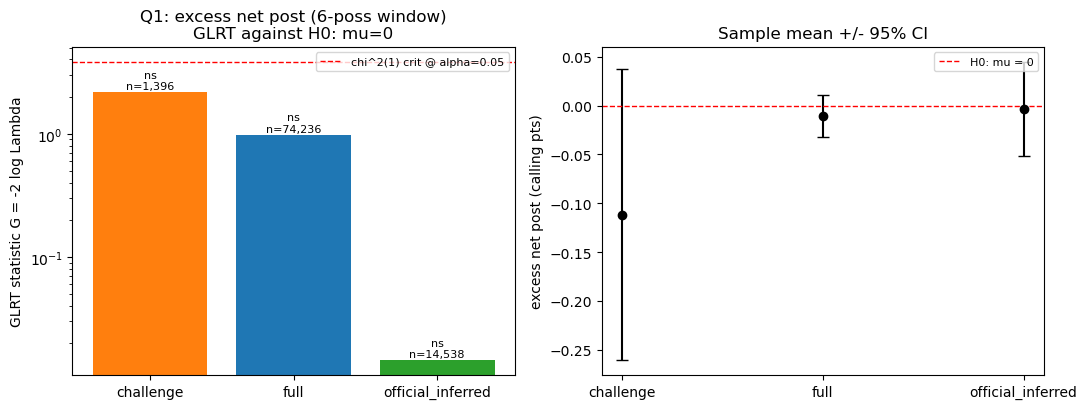

In [8]:
fig = plot_glrt_overall(
    tbl_q1_overall,
    title='Q1: excess net post (6-poss window)',
    metric_label='excess net post (calling pts)',
    save_path=FIG_DIR / 'q1_overall.jpg',
    alpha=ALPHA,
)
plt.show()

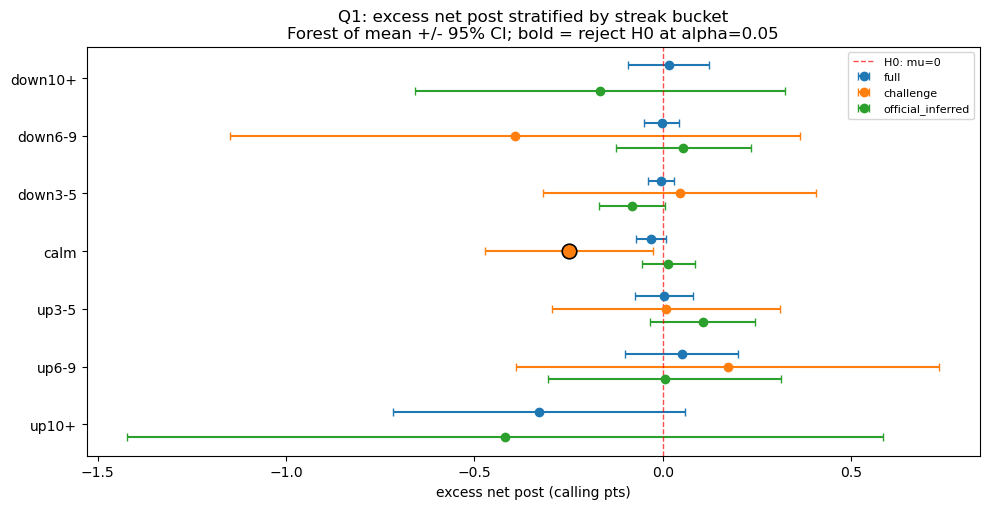

timeout_subtype,streak_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""calm""",623,-0.248678,2.823321,8.020186,7.958345,4.82235,0.028093,-2.198475,0.028283,-0.47081,-0.026547,3.841459,true,"""*"""
"""challenge""","""down3-5""",220,0.045329,2.728853,7.414843,7.412788,0.060971,0.804968,0.246378,0.80562,-0.317268,0.407925,3.841459,false,"""ns"""
"""challenge""","""down6-9""",54,-0.391571,2.770175,7.685088,7.531761,1.088265,0.296856,-1.038724,0.303649,-1.147683,0.364541,3.841459,false,"""ns"""
"""challenge""","""up3-5""",362,0.008688,2.932353,8.575014,8.574938,0.003186,0.954985,0.05637,0.955078,-0.2944,0.311776,3.841459,false,"""ns"""
"""challenge""","""up6-9""",103,0.172074,2.87618,8.221707,8.192097,0.371611,0.542127,0.60718,0.545081,-0.390046,0.734193,3.841459,false,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,-0.082072,2.913683,8.494324,8.487588,3.438106,0.063709,-1.854367,0.063755,-0.168841,0.004698,3.841459,false,"""ns"""
"""official_inferred""","""down6-9""",1146,0.054664,3.096518,9.583045,9.580057,0.357394,0.549957,0.59761,0.550218,-0.124805,0.234132,3.841459,false,"""ns"""
"""official_inferred""","""up10+""",39,-0.418503,3.092782,9.49518,9.320035,0.726099,0.394151,-0.845049,0.403373,-1.421067,0.584061,3.841459,false,"""ns"""


In [9]:
tbl_q1_streak = add_decision_columns(
    run_glrt_groups(events, 'excess_net_post', ['timeout_subtype', 'streak_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q1_streak,
    slice_col='streak_bucket',
    slice_order=STREAK_ORDER,
    title='Q1: excess net post stratified by streak bucket',
    metric_label='excess net post (calling pts)',
    save_path=FIG_DIR / 'q1_streak.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q1_streak

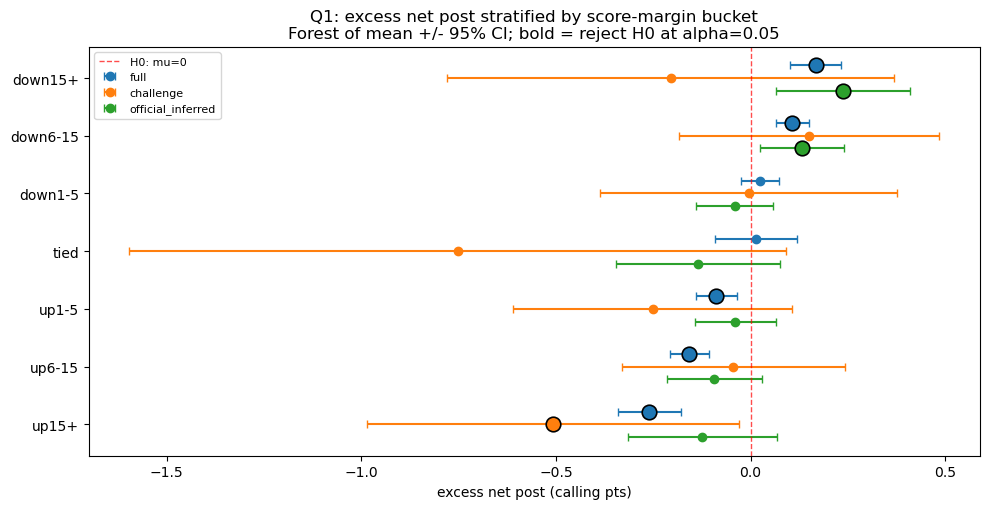

timeout_subtype,margin_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""down1-5""",224,-0.004677,2.898235,8.362286,8.362264,0.000586,0.98069,-0.02415,0.980754,-0.386288,0.376934,3.841459,false,"""ns"""
"""challenge""","""down15+""",93,-0.205686,2.785869,7.719918,7.677612,0.511059,0.474681,-0.712008,0.478261,-0.779429,0.368057,3.841459,false,"""ns"""
"""challenge""","""down6-15""",288,0.150111,2.889114,8.340533,8.318,0.779127,0.377408,0.881744,0.378653,-0.184972,0.485193,3.841459,false,"""ns"""
"""challenge""","""tied""",46,-0.752489,2.840549,8.459552,7.893312,3.1869,0.074231,-1.796706,0.079096,-1.596028,0.09105,3.841459,false,"""ns"""
"""challenge""","""up1-5""",251,-0.25178,2.876399,8.304103,8.24071,1.923468,0.165475,-1.386782,0.166744,-0.609355,0.105796,3.841459,false,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down6-15""",2987,0.131394,3.000898,9.019639,9.002375,5.7229,0.016745,2.393004,0.016772,0.023734,0.239055,3.841459,true,"""*"""
"""official_inferred""","""tied""",743,-0.134843,2.915192,8.505087,8.486905,1.590133,0.207307,-1.26083,0.207766,-0.3448,0.075113,3.841459,false,"""ns"""
"""official_inferred""","""up1-5""",3085,-0.039403,2.945165,8.672736,8.671184,0.552341,0.457363,-0.743109,0.457472,-0.143372,0.064565,3.841459,false,"""ns"""


In [10]:
tbl_q1_margin = add_decision_columns(
    run_glrt_groups(events, 'excess_net_post', ['timeout_subtype', 'margin_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q1_margin,
    slice_col='margin_bucket',
    slice_order=MARGIN_ORDER,
    title='Q1: excess net post stratified by score-margin bucket',
    metric_label='excess net post (calling pts)',
    save_path=FIG_DIR / 'q1_margin.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q1_margin

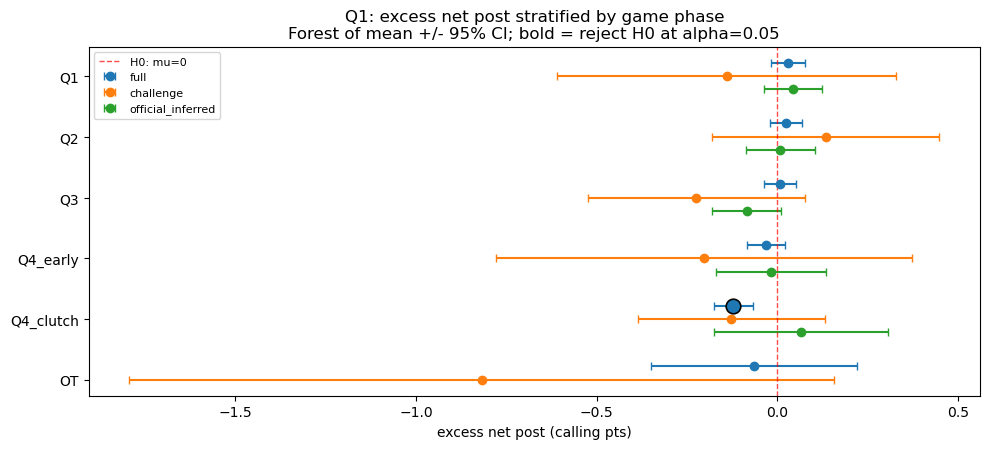

timeout_subtype,time_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""OT""",30,-0.818299,2.612947,7.26952,6.599907,2.899044,0.088632,-1.715309,0.096957,-1.79399,0.157391,3.841459,false,"""ns"""
"""challenge""","""Q1""",150,-0.140576,2.902257,8.3867,8.366939,0.353862,0.551935,-0.593227,0.553929,-0.608828,0.327677,3.841459,false,"""ns"""
"""challenge""","""Q2""",331,0.133883,2.911823,8.471022,8.453098,0.701141,0.4024,0.836519,0.403468,-0.18096,0.448727,3.841459,false,"""ns"""
"""challenge""","""Q3""",356,-0.224014,2.884299,8.345992,8.295809,2.146999,0.142849,-1.465414,0.143693,-0.524654,0.076626,3.841459,false,"""ns"""
"""challenge""","""Q4_clutch""",433,-0.128047,2.738893,7.500608,7.484211,0.947563,0.33034,-0.972836,0.331179,-0.386748,0.130653,3.841459,false,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""Q1""",5209,0.042948,2.962974,8.779375,8.77753,1.094513,0.295473,1.046144,0.295543,-0.037534,0.12343,3.841459,false,"""ns"""
"""official_inferred""","""Q2""",3623,0.008299,2.959066,8.753726,8.753657,0.028508,0.86592,0.168821,0.865947,-0.088087,0.104685,3.841459,false,"""ns"""
"""official_inferred""","""Q3""",3647,-0.084997,2.941995,8.660185,8.652961,3.043678,0.081052,-1.744739,0.081115,-0.180511,0.010517,3.841459,false,"""ns"""


In [11]:
tbl_q1_time = add_decision_columns(
    run_glrt_groups(events, 'excess_net_post', ['timeout_subtype', 'time_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q1_time,
    slice_col='time_bucket',
    slice_order=TIME_ORDER,
    title='Q1: excess net post stratified by game phase',
    metric_label='excess net post (calling pts)',
    save_path=FIG_DIR / 'q1_time.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q1_time

In [12]:
tbl_q1_homeplayoff = add_decision_columns(
    run_glrt_groups(events, 'excess_net_post', ['timeout_subtype', 'is_home_calling', 'IsPlayoff']),
    alpha=ALPHA,
)
tbl_q1_homeplayoff

timeout_subtype,is_home_calling,IsPlayoff,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,bool,bool,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""",false,false,615,-0.198498,2.900146,8.436574,8.397172,2.87897,0.089743,-1.697359,0.090136,-0.428159,0.031163,3.841459,false,"""ns"""
"""challenge""",false,true,32,-0.196462,2.851391,7.91495,7.876353,0.15643,0.692465,-0.389759,0.69938,-1.224498,0.831574,3.841459,false,"""ns"""
"""challenge""",true,false,696,-0.081345,2.778986,7.718284,7.711667,0.596944,0.439746,-0.772232,0.44024,-0.288162,0.125473,3.841459,false,"""ns"""
"""challenge""",true,true,53,0.545952,2.912578,8.621116,8.323052,1.864832,0.172068,1.36463,0.178246,-0.256854,1.348758,3.841459,false,"""ns"""
"""full""",false,false,34798,-0.072295,2.958835,8.759677,8.75445,20.76857,0.000005,-4.557869,0.000005,-0.103384,-0.041206,3.841459,true,"""***"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""full""",true,true,2081,0.143562,3.001527,9.025442,9.004832,4.757478,0.029171,2.181887,0.029229,0.014527,0.272597,3.841459,true,"""*"""
"""official_inferred""",false,false,6811,-0.061813,2.956307,8.742289,8.738468,2.977394,0.084435,-1.725575,0.084469,-0.132034,0.008409,3.841459,false,"""ns"""
"""official_inferred""",false,true,361,-0.297092,2.892628,8.432385,8.344121,3.798579,0.051296,-1.951424,0.051782,-0.59649,0.002307,3.841459,false,"""ns"""


---
## Q2. GLRT on `excess_ppp_for_post`

Tests whether the calling team's PPP in the next ~3 possessions deviates from that team's season PPP.

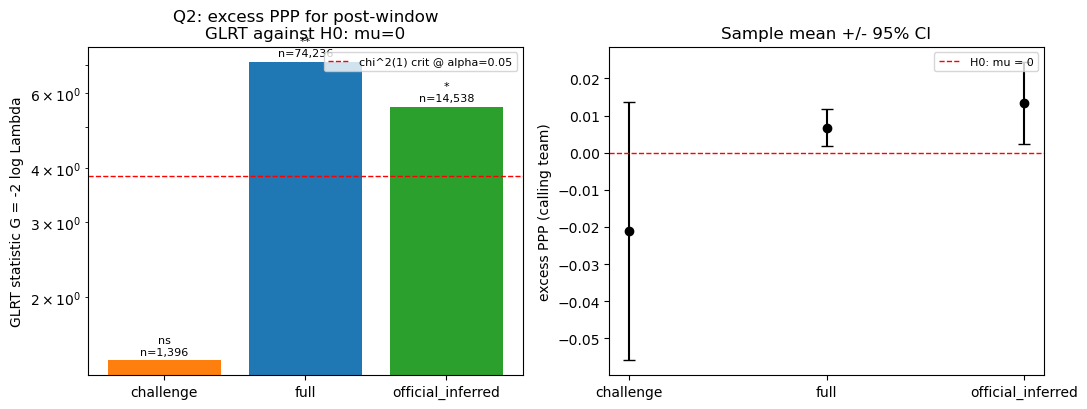

timeout_subtype,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""",1396,-0.021128,0.662598,0.439168,0.438722,1.419748,0.233445,-1.191408,0.233696,-0.055917,0.01366,3.841459,false,"""ns"""
"""full""",74236,0.006733,0.687278,0.47239,0.472345,7.124393,0.007604,2.669202,0.007605,0.001789,0.011677,3.841459,true,"""**"""
"""official_inferred""",14538,0.013404,0.683675,0.467559,0.467379,5.587644,0.018088,2.363966,0.018094,0.00229,0.024518,3.841459,true,"""*"""


In [13]:
tbl_q2_overall = add_decision_columns(
    run_glrt_groups(events, 'excess_ppp_for_post', ['timeout_subtype']), alpha=ALPHA
)
fig = plot_glrt_overall(
    tbl_q2_overall,
    title='Q2: excess PPP for post-window',
    metric_label='excess PPP (calling team)',
    save_path=FIG_DIR / 'q2_overall.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q2_overall

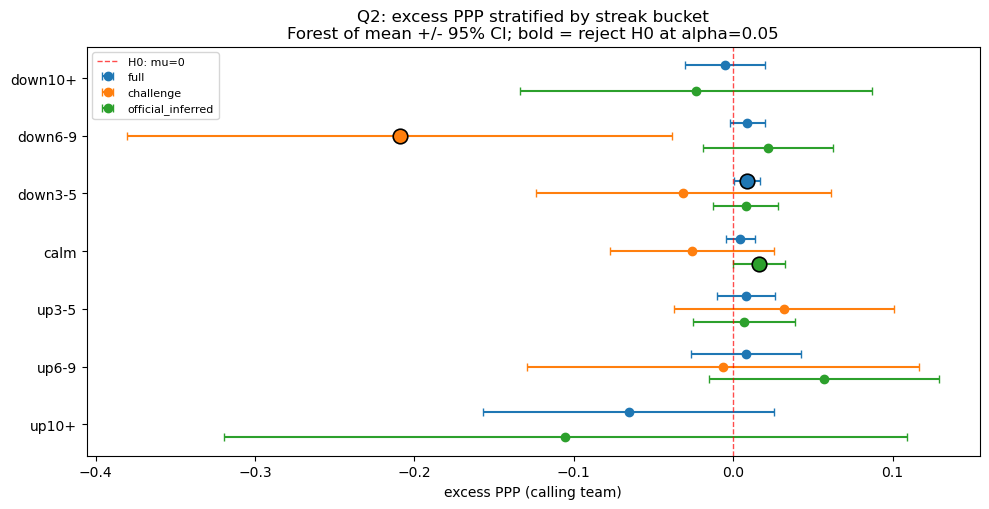

timeout_subtype,streak_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""calm""",623,-0.025789,0.652574,0.425835,0.42517,0.973766,0.323743,-0.986389,0.324326,-0.077132,0.025554,3.841459,false,"""ns"""
"""challenge""","""down3-5""",220,-0.031321,0.695861,0.483002,0.482021,0.447283,0.503628,-0.66761,0.505086,-0.123783,0.061142,3.841459,false,"""ns"""
"""challenge""","""down6-9""",54,-0.20909,0.626457,0.4289,0.385181,5.805534,0.015976,-2.452672,0.017505,-0.38008,-0.0381,3.841459,true,"""*"""
"""challenge""","""up3-5""",362,0.031755,0.668478,0.446637,0.445628,0.818208,0.365705,0.903809,0.366699,-0.037339,0.100849,3.841459,false,"""ns"""
"""challenge""","""up6-9""",103,-0.00655,0.629443,0.392394,0.392352,0.011263,0.91548,-0.105615,0.916095,-0.129568,0.116468,3.841459,false,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,0.007892,0.685005,0.469186,0.469123,0.575415,0.448115,0.758499,0.448194,-0.012507,0.028292,3.841459,false,"""ns"""
"""official_inferred""","""down6-9""",1146,0.021837,0.708568,0.502108,0.501631,1.088857,0.296725,1.043276,0.297041,-0.019231,0.062904,3.841459,false,"""ns"""
"""official_inferred""","""up10+""",39,-0.105206,0.6602,0.435756,0.424688,1.003405,0.316488,-0.995169,0.325949,-0.319218,0.108806,3.841459,false,"""ns"""


In [14]:
tbl_q2_streak = add_decision_columns(
    run_glrt_groups(events, 'excess_ppp_for_post', ['timeout_subtype', 'streak_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q2_streak,
    slice_col='streak_bucket',
    slice_order=STREAK_ORDER,
    title='Q2: excess PPP stratified by streak bucket',
    metric_label='excess PPP (calling team)',
    save_path=FIG_DIR / 'q2_streak.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q2_streak

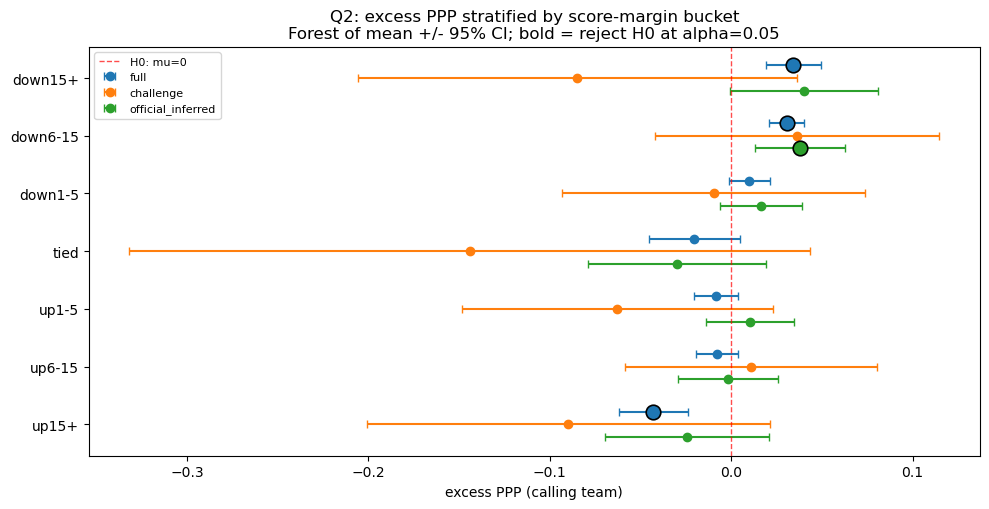

timeout_subtype,margin_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""down1-5""",224,-0.009733,0.635923,0.402688,0.402593,0.052699,0.818431,-0.229064,0.819029,-0.093465,0.073999,3.841459,false,"""ns"""
"""challenge""","""down15+""",93,-0.084804,0.587664,0.348827,0.341635,1.937428,0.163948,-1.391653,0.167383,-0.205832,0.036224,3.841459,false,"""ns"""
"""challenge""","""down6-15""",288,0.036311,0.67694,0.457974,0.456656,0.83034,0.362174,0.910302,0.363427,-0.042201,0.114823,3.841459,false,"""ns"""
"""challenge""","""tied""",46,-0.144233,0.631967,0.411503,0.3907,2.386335,0.1224,-1.547925,0.128645,-0.331904,0.043438,3.841459,false,"""ns"""
"""challenge""","""up1-5""",251,-0.062854,0.689969,0.478111,0.474161,2.082644,0.148982,-1.443252,0.150201,-0.148627,0.022918,3.841459,false,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down6-15""",2987,0.03804,0.691979,0.480122,0.478675,9.016117,0.002676,3.004449,0.002683,0.013214,0.062866,3.841459,true,"""**"""
"""official_inferred""","""tied""",743,-0.02998,0.678967,0.461275,0.460376,1.449156,0.228663,-1.203585,0.229134,-0.07888,0.01892,3.841459,false,"""ns"""
"""official_inferred""","""up1-5""",3085,0.010221,0.688146,0.473495,0.473391,0.680781,0.409318,0.825007,0.409432,-0.014071,0.034514,3.841459,false,"""ns"""


In [15]:
tbl_q2_margin = add_decision_columns(
    run_glrt_groups(events, 'excess_ppp_for_post', ['timeout_subtype', 'margin_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q2_margin,
    slice_col='margin_bucket',
    slice_order=MARGIN_ORDER,
    title='Q2: excess PPP stratified by score-margin bucket',
    metric_label='excess PPP (calling team)',
    save_path=FIG_DIR / 'q2_margin.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q2_margin

---
## Q3. GLRT on `wp_added_calling`

Tests whether the calling team's win probability moves across the ±6-possession window. Strongest signal in our data — the LR WP model translates point swings into a directly meaningful currency.

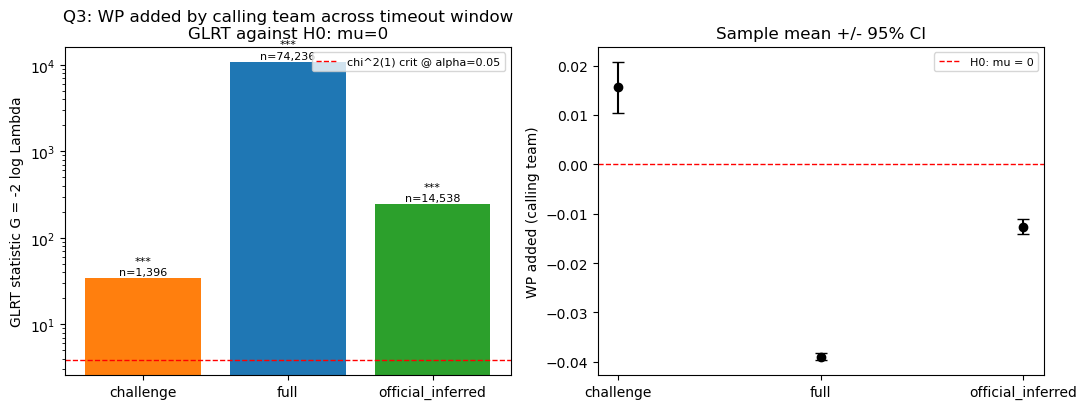

timeout_subtype,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""",1396,0.015601,0.098922,0.010022,0.009779,34.320573,4.6741e-9,5.892457,4.7635e-9,0.010407,0.020795,3.841459,true,"""***"""
"""full""",74236,-0.038974,0.098095,0.011141,0.009622,10880.699899,0.0,-108.251359,0.0,-0.039679,-0.038268,3.841459,true,"""***"""
"""official_inferred""",14538,-0.012627,0.096827,0.009534,0.009375,245.18525,0.0,-15.724104,0.0,-0.014201,-0.011053,3.841459,true,"""***"""


In [16]:
tbl_q3_overall = add_decision_columns(
    run_glrt_groups(events, 'wp_added_calling', ['timeout_subtype']), alpha=ALPHA
)
fig = plot_glrt_overall(
    tbl_q3_overall,
    title='Q3: WP added by calling team across timeout window',
    metric_label='WP added (calling team)',
    save_path=FIG_DIR / 'q3_overall.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q3_overall

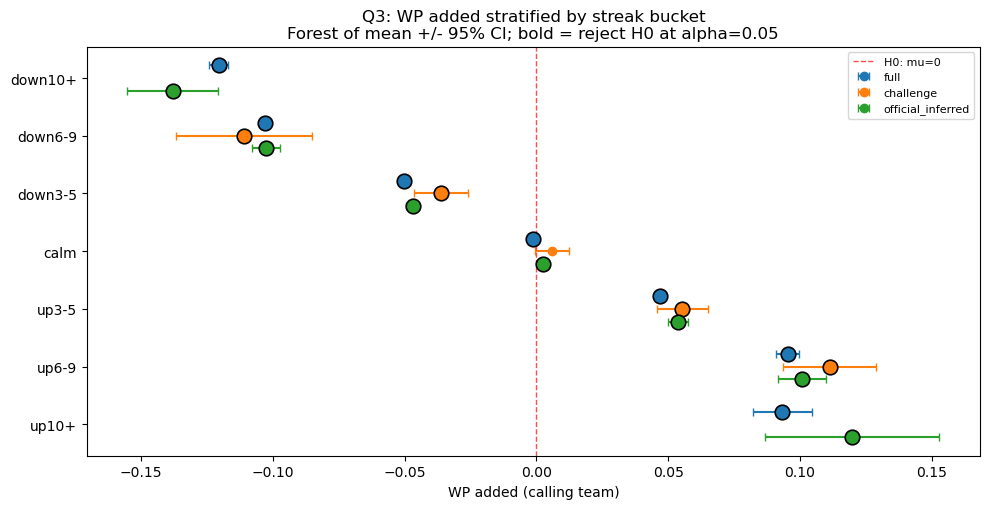

timeout_subtype,streak_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""calm""",623,0.00589,0.082036,0.006754,0.006719,3.208357,0.073263,1.792057,0.07361,-0.000564,0.012344,3.841459,false,"""ns"""
"""challenge""","""down3-5""",220,-0.036283,0.077448,0.007287,0.005971,43.833144,3.5760e-11,-6.948698,4.1622e-11,-0.046574,-0.025992,3.841459,true,"""***"""
"""challenge""","""down6-9""",54,-0.111069,0.094345,0.021073,0.008736,47.547095,5.3698e-12,-8.651116,1.0353e-11,-0.136821,-0.085318,3.841459,true,"""***"""
"""challenge""","""up3-5""",362,0.055343,0.092796,0.01165,0.008587,110.42285,0.0,11.347203,0.0,0.045752,0.064934,3.841459,true,"""***"""
"""challenge""","""up6-9""",103,0.111207,0.090951,0.020559,0.008192,94.776148,0.0,12.40918,0.0,0.093432,0.128983,3.841459,true,"""***"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down3-5""",4334,-0.046973,0.084895,0.009412,0.007206,1157.775204,0.0,-36.425995,0.0,-0.049501,-0.044445,3.841459,true,"""***"""
"""official_inferred""","""down6-9""",1146,-0.102504,0.091287,0.018833,0.008326,935.405096,0.0,-38.012528,0.0,-0.107795,-0.097213,3.841459,true,"""***"""
"""official_inferred""","""up10+""",39,0.119853,0.101844,0.024471,0.010106,34.489294,4.2860e-9,7.349336,8.3234e-9,0.086839,0.152867,3.841459,true,"""***"""


In [17]:
tbl_q3_streak = add_decision_columns(
    run_glrt_groups(events, 'wp_added_calling', ['timeout_subtype', 'streak_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q3_streak,
    slice_col='streak_bucket',
    slice_order=STREAK_ORDER,
    title='Q3: WP added stratified by streak bucket',
    metric_label='WP added (calling team)',
    save_path=FIG_DIR / 'q3_streak.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q3_streak

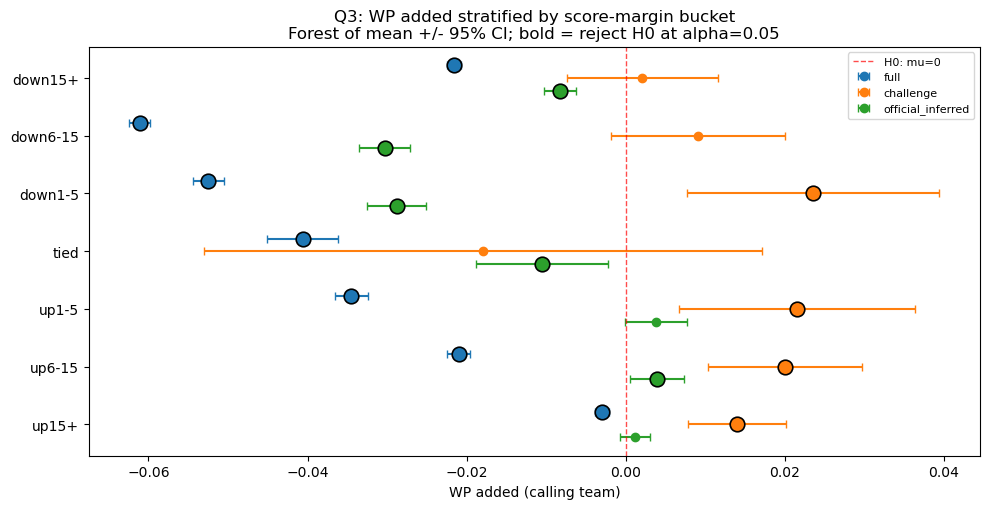

timeout_subtype,margin_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""down1-5""",224,0.02355,0.120672,0.015051,0.014497,8.409841,0.003732,2.920864,0.003849,0.007661,0.039439,3.841459,true,"""**"""
"""challenge""","""down15+""",93,0.002075,0.045997,0.002097,0.002093,0.191101,0.662002,0.435018,0.664568,-0.007398,0.011548,3.841459,false,"""ns"""
"""challenge""","""down6-15""",288,0.009042,0.094172,0.008919,0.008838,2.651804,0.103432,1.629356,0.104335,-0.001881,0.019964,3.841459,false,"""ns"""
"""challenge""","""tied""",46,-0.017969,0.118079,0.013962,0.013639,1.076277,0.299532,-1.032131,0.307526,-0.053034,0.017096,3.841459,false,"""ns"""
"""challenge""","""up1-5""",251,0.021546,0.119456,0.014677,0.014213,8.067635,0.004506,2.857626,0.004628,0.006696,0.036397,3.841459,true,"""**"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""down6-15""",2987,-0.030319,0.090898,0.009179,0.00826,315.199099,0.0,-18.229619,0.0,-0.03358,-0.027058,3.841459,true,"""***"""
"""official_inferred""","""tied""",743,-0.010557,0.115142,0.013351,0.01324,6.228445,0.012571,-2.499241,0.012661,-0.01885,-0.002264,3.841459,true,"""*"""
"""official_inferred""","""up1-5""",3085,0.003773,0.111015,0.012335,0.01232,3.563227,0.059073,1.88789,0.059134,-0.000146,0.007692,3.841459,false,"""ns"""


In [18]:
tbl_q3_margin = add_decision_columns(
    run_glrt_groups(events, 'wp_added_calling', ['timeout_subtype', 'margin_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q3_margin,
    slice_col='margin_bucket',
    slice_order=MARGIN_ORDER,
    title='Q3: WP added stratified by score-margin bucket',
    metric_label='WP added (calling team)',
    save_path=FIG_DIR / 'q3_margin.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q3_margin

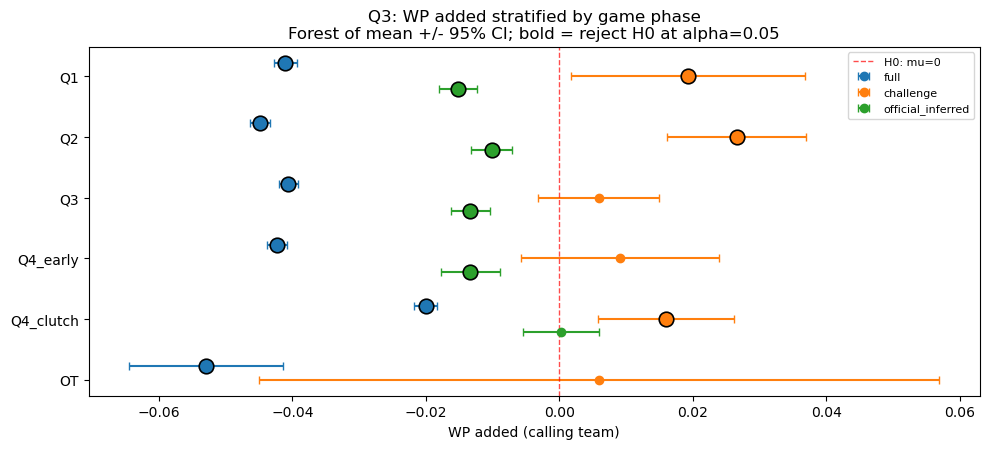

timeout_subtype,time_bucket,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str
"""challenge""","""OT""",30,0.006017,0.136508,0.018049,0.018013,0.060226,0.806139,0.241406,0.810939,-0.044956,0.056989,3.841459,false,"""ns"""
"""challenge""","""Q1""",150,0.019309,0.108611,0.01209,0.011718,4.698346,0.030192,2.177357,0.031028,0.001786,0.036832,3.841459,true,"""*"""
"""challenge""","""Q2""",331,0.026619,0.096476,0.009988,0.009279,24.355672,8.0091e-7,5.019739,8.4803e-7,0.016187,0.03705,3.841459,true,"""***"""
"""challenge""","""Q3""",356,0.005888,0.086455,0.007488,0.007453,1.652265,0.198651,1.285089,0.199599,-0.003123,0.0149,3.841459,false,"""ns"""
"""challenge""","""Q4_clutch""",433,0.015991,0.107989,0.01189,0.011635,9.412988,0.002155,3.081245,0.002193,0.00579,0.026191,3.841459,true,"""**"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""","""Q1""",5209,-0.015175,0.106713,0.011616,0.011386,104.302861,0.0,-10.26323,0.0,-0.018074,-0.012276,3.841459,true,"""***"""
"""official_inferred""","""Q2""",3623,-0.01013,0.095532,0.009226,0.009124,40.522808,1.9433e-10,-6.382713,1.9601e-10,-0.013242,-0.007018,3.841459,true,"""***"""
"""official_inferred""","""Q3""",3647,-0.013349,0.090552,0.008376,0.008197,78.425202,0.0,-8.902403,0.0,-0.016289,-0.010409,3.841459,true,"""***"""


In [19]:
tbl_q3_time = add_decision_columns(
    run_glrt_groups(events, 'wp_added_calling', ['timeout_subtype', 'time_bucket']), alpha=ALPHA
)
fig = plot_glrt_by_slice(
    tbl_q3_time,
    slice_col='time_bucket',
    slice_order=TIME_ORDER,
    title='Q3: WP added stratified by game phase',
    metric_label='WP added (calling team)',
    save_path=FIG_DIR / 'q3_time.jpg',
    alpha=ALPHA,
)
plt.show()
tbl_q3_time

---
## Empirical Distribution of GLRT Statistics

Sanity check: pool every GLRT statistic produced above and overlay against the asymptotic $\chi^2_1$ reference. If H0 held everywhere, the histogram should track the chi-squared density; an excess in the right tail signals real effects.

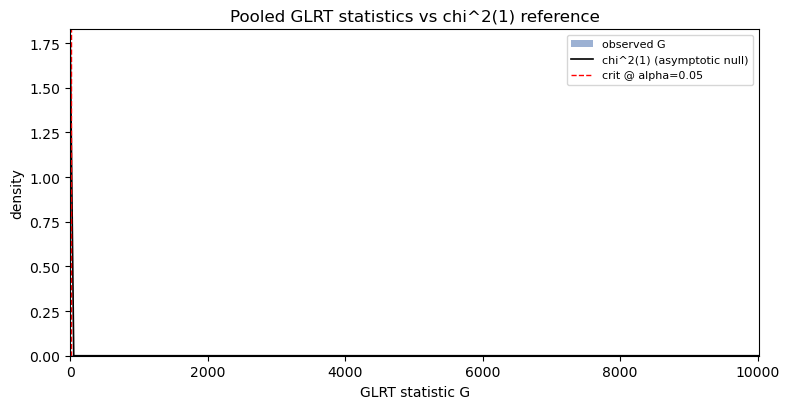

tests run: 163, rejected at alpha=0.05: 69


In [20]:
all_tables = [
    tbl_q1_overall, tbl_q1_streak, tbl_q1_margin, tbl_q1_time,
    tbl_q2_overall, tbl_q2_streak, tbl_q2_margin,
    tbl_q3_overall, tbl_q3_streak, tbl_q3_margin, tbl_q3_time,
]
all_g = pl.concat([t.select('glrt_stat') for t in all_tables])['glrt_stat'].to_numpy()
fig = plot_glrt_distribution(
    all_g,
    title='Pooled GLRT statistics vs chi^2(1) reference',
    save_path=FIG_DIR / 'glrt_null_distribution.jpg',
    alpha=ALPHA,
)
plt.show()
print(f'tests run: {len(all_g)}, rejected at alpha={ALPHA}: {(all_g > critical_value(ALPHA)).sum()}')

---
## Combined Summary Table

All tests in a single dataframe (one row per metric, slice, and group).

In [21]:
def _tag(df: pl.DataFrame, metric: str, slice_name: str) -> pl.DataFrame:
    return df.with_columns(pl.lit(metric).alias('metric'), pl.lit(slice_name).alias('slice'))

summary_rows = pl.concat([
    _tag(tbl_q1_overall, 'excess_net_post', 'overall'),
    _tag(tbl_q1_streak, 'excess_net_post', 'streak_bucket'),
    _tag(tbl_q1_margin, 'excess_net_post', 'margin_bucket'),
    _tag(tbl_q1_time, 'excess_net_post', 'time_bucket'),
    _tag(tbl_q2_overall, 'excess_ppp_for_post', 'overall'),
    _tag(tbl_q2_streak, 'excess_ppp_for_post', 'streak_bucket'),
    _tag(tbl_q2_margin, 'excess_ppp_for_post', 'margin_bucket'),
    _tag(tbl_q3_overall, 'wp_added_calling', 'overall'),
    _tag(tbl_q3_streak, 'wp_added_calling', 'streak_bucket'),
    _tag(tbl_q3_margin, 'wp_added_calling', 'margin_bucket'),
    _tag(tbl_q3_time, 'wp_added_calling', 'time_bucket'),
], how='diagonal')
summary_rows.write_csv('/Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/Report/stats-signals/glrt_summary.csv')
print(f'summary rows: {summary_rows.shape}')
summary_rows.head(20)

summary rows: (163, 20)


timeout_subtype,n,mean,std,sigma2_h0,sigma2_h1,glrt_stat,glrt_p,t_stat,t_p,ci_low,ci_high,crit,reject_h0,signif,metric,slice,streak_bucket,margin_bucket,time_bucket
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,str,str,str,str,str,str
"""challenge""",1396,-0.111779,2.84021,8.073507,8.061012,2.16212,0.141449,-1.470458,0.141663,-0.260898,0.03734,3.841459,false,"""ns""","""excess_net_post""","""overall""",null,null,null
"""full""",74236,-0.010753,2.957297,8.745605,8.74549,0.981443,0.321843,-0.990675,0.321848,-0.032026,0.010521,3.841459,false,"""ns""","""excess_net_post""","""overall""",null,null,null
"""official_inferred""",14538,-0.00296,2.959139,8.755912,8.755904,0.01455,0.903989,-0.120619,0.903994,-0.051066,0.045146,3.841459,false,"""ns""","""excess_net_post""","""overall""",null,null,null
"""challenge""",623,-0.248678,2.823321,8.020186,7.958345,4.82235,0.028093,-2.198475,0.028283,-0.47081,-0.026547,3.841459,true,"""*""","""excess_net_post""","""streak_bucket""","""calm""",null,null
"""challenge""",220,0.045329,2.728853,7.414843,7.412788,0.060971,0.804968,0.246378,0.80562,-0.317268,0.407925,3.841459,false,"""ns""","""excess_net_post""","""streak_bucket""","""down3-5""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""official_inferred""",6736,0.014662,2.951168,8.708316,8.708101,0.166292,0.683429,0.407761,0.683462,-0.055826,0.085151,3.841459,false,"""ns""","""excess_net_post""","""streak_bucket""","""calm""",null,null
"""official_inferred""",130,-0.166269,2.834449,7.999944,7.972299,0.450016,0.502327,-0.668826,0.504802,-0.658125,0.325588,3.841459,false,"""ns""","""excess_net_post""","""streak_bucket""","""down10+""",null,null
"""official_inferred""",4334,-0.082072,2.913683,8.494324,8.487588,3.438106,0.063709,-1.854367,0.063755,-0.168841,0.004698,3.841459,false,"""ns""","""excess_net_post""","""streak_bucket""","""down3-5""",null,null
